<div style="
background-color:#EAEAEA;
padding:20px;
border-left:5px solid #6C757D;
border-radius:6px;">

<table style="width:100%; border:none;">
<tr style="border:none;">

<td style="border:none; vertical-align:top;">

<h1 style="font-size:32px; margin-top:0;">
Master's Thesis
</h1>

<hr style="margin:16px 0 22px 0;">

<p style="font-size:22px; line-height:1.5; margin:0;">
<strong>Master's Degree in Advanced Physics</strong> - 
<strong>Universitat de Val?ncia</strong>
</p>

<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">
This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:
</p>

<div style="
font-size:25px;
font-weight:700;
line-height:1.3;
margin-top:14px;
margin-bottom:26px;">
Fast Simulation of Neutrino Oscillations in Matter
</div>

<p style="font-size:14px; line-height:1.55;">
<strong>Author</strong><br>
Juan Ramon Diaz Santos - 
<a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a>
</p>

<p style="font-size:14px; line-height:1.55;">
<strong>Supervisors</strong><br>
Roberto Ruiz de Austri Bazan ?
<a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>
Michele Lucente ?
<a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a>
</p>

<p style="font-size:14px; line-height:1.55; margin-bottom:0;">
<strong>Date</strong><br>
September 2026
</p>

</td>

<td style="
border:none;
width:230px;
padding-left:25px;
text-align:right;
vertical-align:top;">

<img src="../../logo_uv.png"
     alt="Universitat de Val?ncia"
     style="width:200px; margin-top:5px;">

</td>

</tr>
</table>

</div>

# Intrinsic Validation 1 — Perturbative versus Numerical Propagation

This notebook validates the internal consistency of TPeanuts by comparing the first-order perturbative (`analytical`) and segmented matrix-exponential (`numerical`) propagation paths in four physical scenarios.

---

## Table of Contents

| # | Section |
|---|---------|
| [0](#0.-Theory-Background) | **Theory Background**: evolution operator, perturbative expansion, numerical reference, physical pipelines |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration**: directories, physical grids and validation helpers |
| [3](#3.-Pure-Flavour-States-through-Earth) | **Pure Flavour States through Earth** |
| [4](#4.-Solar-Neutrinos-to-the-Detector) | **Solar Neutrinos to the Detector** |
| [5](#5.-Atmospheric-Neutrinos-to-the-Surface) | **Atmospheric Neutrinos to the Surface** |
| [6](#6.-Atmospheric-Neutrinos-to-the-Detector) | **Atmospheric Neutrinos to the Detector** |
| [∑](#7.-Summary) | **Summary** |

## 0. Theory Background

### 0.1 Evolution in matter

A neutrino flavour state obeys $i\,d\psi/dx=H(x)\psi$, with the three-flavour matter Hamiltonian *(Wolfenstein 1978; Mikheyev & Smirnov 1985)*

$$H(x)=\frac{1}{2E}U\,\mathrm{diag}(0,\Delta m^2_{21},\Delta m^2_{31})U^\dagger+\mathrm{diag}(\sqrt{2}G_F n_e(x),0,0).$$

The evolution operator is the path-ordered exponential $S(x_2,x_1)=\mathcal{T}\exp[-i\int_{x_1}^{x_2}H(x)dx]$, and the coherent transition probability is $P_{\alpha\to\beta}=|S_{\beta\alpha}|^2$.

### 0.2 Perturbative analytical evolution

Within each material segment TPeanuts decomposes $n_e(x)=\bar n_e+\delta n_e(x)$. The constant-density contribution $S_0$ is evaluated exactly and the residual profile contributes the first Dyson term *(Akhmedov, Maltoni & Smirnov 2007)*,

$$S\simeq S_0+S_1,\qquad S_1=-i\int_{x_1}^{x_2}S_0(x_2,x)\,\delta H(x)\,S_0(x,x_1)\,dx.$$

Earth uses layered radial polynomials. The atmosphere is fitted automatically by local polynomials in a normalized segment coordinate, so its residual oscillatory integrals are also analytical.

### 0.3 Segmented numerical reference

The numerical branch samples the density and approximates each short interval by a constant Hamiltonian, $S_j=\exp(-iH_j\Delta x_j)$. Ordered multiplication converges to the path-ordered exponential as the maximum step tends to zero. It therefore supplies an intrinsic reference independent of the residual-density expansion.

### 0.4 Physical scenarios

Pure flavour states test every column of the Earth transition matrix. Solar neutrinos reach Earth as incoherent mass-eigenstate weights because the Sun–Earth baseline averages relative phases *(Giunti & Kim 2007)*. Atmospheric neutrinos remain coherent over the atmosphere and Earth baselines, so the detector calculation composes amplitudes as $S_{\rm total}=S_{\rm Earth}S_{\rm atm}$ before taking the modulus squared.

### 0.5 Validation observables

For every probability $P$, this notebook reports $|\Delta P|=|P_{\rm analytical}-P_{\rm numerical}|$ and $|\Delta P|/\max(|P_{\rm numerical}|,10^{-12})$. It also checks $\sum_\beta P_{\alpha\to\beta}=1$.

### References

- L. Wolfenstein, *Neutrino oscillations in matter*, Phys. Rev. D **17**, 2369 (1978).
- S. P. Mikheyev and A. Yu. Smirnov, *Resonant amplification of neutrino oscillations in matter*, Sov. J. Nucl. Phys. **42**, 913 (1985).
- E. K. Akhmedov, M. Maltoni and A. Yu. Smirnov, *1-3 leptonic mixing and the neutrino oscillograms of the Earth*, JHEP **05**, 077 (2007); perturbative evolution formalism and matter-profile treatment.
- C. Giunti and C. W. Kim, *Fundamentals of Neutrino Physics and Astrophysics*, Oxford University Press (2007).

## 1. Libraries

In [1]:
from __future__ import annotations

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import save_and_show, to_numpy
from tpeanuts.core.common.oscillation import OscillationParameters
from tpeanuts.config.propagation import PropagationConfig
from tpeanuts.medium.earth.profile import EarthParameters, EarthProfile
from tpeanuts.medium.earth.probability import earth_probability_state
from tpeanuts.medium.solar.profile import SolarProfile
from tpeanuts.medium.solar.probability import solar_probability_mass
from tpeanuts.medium.atmosphere.profile import AtmosphereParameters
from tpeanuts.medium.atmosphere.evolutor import atmosphere_evolutor
from tpeanuts.medium.atmosphere.probability import atmosphere_probability_transition
from tpeanuts.util.context import RuntimeContext

## 2. Paths and Configuration

### 2.1 Paths

`load_notebook_config()` resolves the package directory and applies the common plotting, Torch and NumPy style. Following the notebook-relative convention, all generated figures and tables are saved under `validation/intrinsic/`.

**Expected results:** the package and output directories exist, and the runtime device and dtype match the shared notebook configuration.

In [2]:
config = load_notebook_config()
DEVICE, DTYPE = config.device, config.dtype
context = RuntimeContext.resolve(DEVICE, DTYPE)
OUTPUT_DIR = config.output_dir('validation', 'intrinsic')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Package dir : {config.package_dir}')
print(f'Output dir  : {OUTPUT_DIR}')
print(f'Device      : {context.device}   dtype: {context.dtype}')

Package dir : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Output dir  : v:\output\validation\intrinsic
Device      : cpu   dtype: torch.float64


### 2.2 Configuration

All calculations use the NuFIT 5.2 normal-ordering preset and ordinary neutrinos. Earth is represented by the package PREM polynomial profile; the numerical Earth reference uses 400 midpoint segments. The atmospheric analytical branch uses six cubic local fits, while its numerical reference uses 600 segments. A 1 km detector depth exercises both surface-crossing and shallow underground geometry.

| Parameter | Value | Description |
|-----------|-------|-------------|
| Oscillation preset | `_SM_NUFIT52_NO` | Three-flavour normal ordering |
| Earth profile | PREM even-power layers | Shared physical density in both methods |
| Earth numerical steps | 400 | Midpoint constant-density segments |
| Earth reunitarization | Enabled | Projects the first-order analytical operator to the nearest unitary matrix |
| Atmosphere profile | Exponential | Electron density along spherical trajectories |
| Atmosphere analytical fit | 6 cubic segments | Automatically inferred coefficients |
| Atmosphere numerical steps | 600 | Matrix-exponential reference |
| Energy and angular grids | 90 points each | Used in every two-dimensional comparison |
| Detector depth | 1000 m | Buried detector |
| Relative-difference floor | $10^{-12}$ | Stabilizes ratios close to zero |

**Expected results:** all profiles load successfully and every probability tensor uses the configured device and real/complex precision.

In [3]:
CDTYPE = torch.complex128 if DTYPE == torch.float64 else torch.complex64
oscillation = PropagationConfig.oscillation_parameters_from_preset('_SM_NUFIT52_NO', context=context, antinu=False)
earth = EarthProfile(params=EarthParameters(profile_perturbative_kwargs={'density_file': str(config.earth_density_file), 'tabulated_density': False}), context=context)
solar = SolarProfile.default(context=context)
atmosphere = AtmosphereParameters(atmosphere_density_source='exponential', nsteps=600, matter=True, perturbative_segments=6, perturbative_degree=3)
DEPTH_M, N_EARTH_STEPS = 1000.0, 400
FLAVOURS = ('nu_e', 'nu_mu', 'nu_tau')
BASIS = torch.eye(3, device=DEVICE, dtype=CDTYPE)
print(f'Oscillation preset: {oscillation.preset_name} ({oscillation.ordering})')
print(f'Earth steps={N_EARTH_STEPS}; atmosphere steps={atmosphere.nsteps}; analytical atmosphere={atmosphere.perturbative_segments}x degree {atmosphere.perturbative_degree}')

Oscillation preset: _SM_NUFIT52_NO (NO)
Earth steps=400; atmosphere steps=600; analytical atmosphere=6x degree 3


### 2.3 Validation helpers

Three notebook-specific helpers are required: one computes common discrepancy and normalization metrics, one draws the repeated two-dimensional error maps, and one creates the common $3\times2$ probability/error comparison grid.

**Expected results:** each scenario appends one finite summary row and writes one figure into `OUTPUT_DIR`.

In [4]:
REL_FLOOR = 1e-12
summaries = []

def metrics(name, analytical, numerical):
    absolute = torch.abs(analytical - numerical)
    relative = absolute / torch.clamp(torch.abs(numerical), min=REL_FLOOR)
    norm_a = torch.amax(torch.abs(analytical.sum(dim=-1) - 1.0)).item()
    norm_n = torch.amax(torch.abs(numerical.sum(dim=-1) - 1.0)).item()
    row = {'case': name, 'max_abs': absolute.max().item(), 'mean_abs': absolute.mean().item(), 'max_rel': relative.max().item(), 'normalization_analytical': norm_a, 'normalization_numerical': norm_n}
    summaries.append(row); display(pd.DataFrame([row]).set_index('case'))
    return absolute, relative

def heatmap(absolute, relative, x, y, title, xlabel, ylabel, filename):
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), sharex=True, sharey=True)
    for ax, values, subtitle, label in zip(axes, (absolute, relative), ('Absolute error', 'Relative error'), ('maximum |Delta P|', 'maximum |Delta P| / max(|P_num|, 1e-12)')):
        im = ax.pcolormesh(to_numpy(x), to_numpy(y), to_numpy(values).T, shading='auto', cmap='magma')
        ax.set(xlabel=xlabel, ylabel=ylabel, title=subtitle); fig.colorbar(im, ax=ax, label=label)
    fig.suptitle(title)
    fig.tight_layout(); save_and_show(filename, fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

def comparison_grid(analytical, numerical, energy, angle, fixed_angle, fixed_energy, title, angle_label, filename, log_energy=False):
    i_angle = int(torch.argmin(torch.abs(angle - fixed_angle)))
    i_energy = int(torch.argmin(torch.abs(energy - fixed_energy)))
    absolute = torch.abs(analytical - numerical)
    relative = absolute / torch.clamp(torch.abs(numerical), min=REL_FLOOR)
    fig, axes = plt.subplots(3, 2, figsize=(13.5, 11), sharex='col')
    colours = ('C0', 'C1', 'C2')
    for flavour, (label, colour) in enumerate(zip(FLAVOURS, colours)):
        axes[0, 0].plot(to_numpy(energy), to_numpy(analytical[:, i_angle, flavour]), color=colour, label=f'{label} analytical')
        axes[0, 0].plot(to_numpy(energy), to_numpy(numerical[:, i_angle, flavour]), '--', color=colour, label=f'{label} numerical')
        axes[1, 0].plot(to_numpy(energy), to_numpy(absolute[:, i_angle, flavour]), color=colour, label=label)
        axes[2, 0].plot(to_numpy(energy), to_numpy(relative[:, i_angle, flavour]), color=colour, label=label)
        axes[0, 1].plot(to_numpy(angle), to_numpy(analytical[i_energy, :, flavour]), color=colour, label=f'{label} analytical')
        axes[0, 1].plot(to_numpy(angle), to_numpy(numerical[i_energy, :, flavour]), '--', color=colour, label=f'{label} numerical')
        axes[1, 1].plot(to_numpy(angle), to_numpy(absolute[i_energy, :, flavour]), color=colour, label=label)
        axes[2, 1].plot(to_numpy(angle), to_numpy(relative[i_energy, :, flavour]), color=colour, label=label)
    axes[0, 0].set_title(f'Energy scan at {angle_label}={float(angle[i_angle]):.3g}')
    axes[0, 1].set_title(f'Angular scan at E={float(energy[i_energy]):.3g} MeV')
    for ax in axes[0]: ax.set_ylabel('Probability'); ax.set_ylim(-0.02, 1.02); ax.legend(fontsize=7, ncol=2)
    for ax in axes[1]: ax.set_ylabel('Absolute error'); ax.set_yscale('log')
    for ax in axes[2]: ax.set_ylabel('Relative error'); ax.set_yscale('log')
    axes[2, 0].set_xlabel('E [MeV]'); axes[2, 1].set_xlabel(angle_label)
    if log_energy:
        for ax in axes[:, 0]: ax.set_xscale('log')
    for ax in axes.flat: ax.grid(alpha=0.25)
    fig.suptitle(title); fig.tight_layout(); save_and_show(filename, fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

## 3. Pure flavour states through Earth

Each flavour basis vector is propagated coherently through Earth over an energy–nadir grid. The numerical path uses 400 midpoint segments per trajectory. The parallel heatmaps show the maximum absolute and relative discrepancies over initial and final flavour. The additional $3\times2$ grid selects an initial $\nu_e$: its left column scans energy near $\eta=0.60$ rad and its right column scans nadir angle near $E=5$ GeV.

**Expected results:** both methods conserve total probability. The largest differences should occur for long core-crossing paths and around energies where the matter phase is most sensitive to the density approximation; discrepancies should decrease when increasing the perturbative resolution.

,max_abs,mean_abs,max_rel,normalization_analytical,normalization_numerical
case,,,,,
pure flavour through Earth,0.01164,0.000463,8.614473,2.664535e-15,3.290701e-13


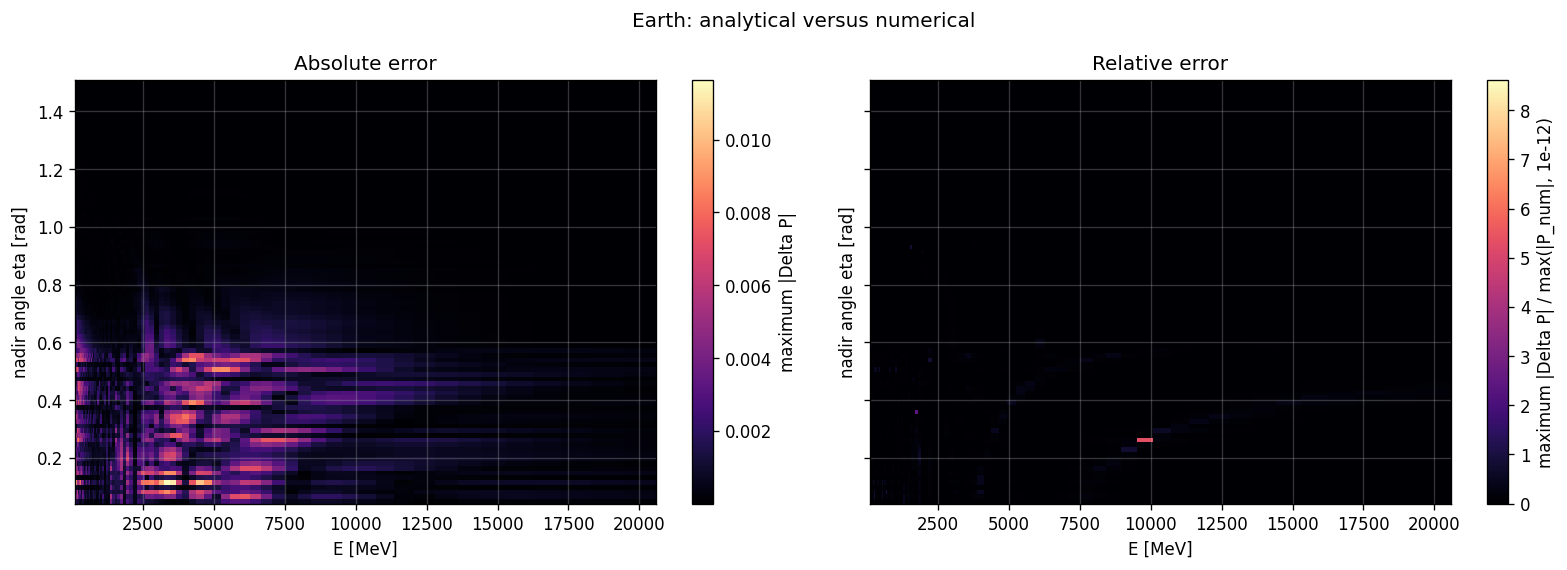

v:\output\validation\intrinsic\intrinsic1_fig1_earth.png


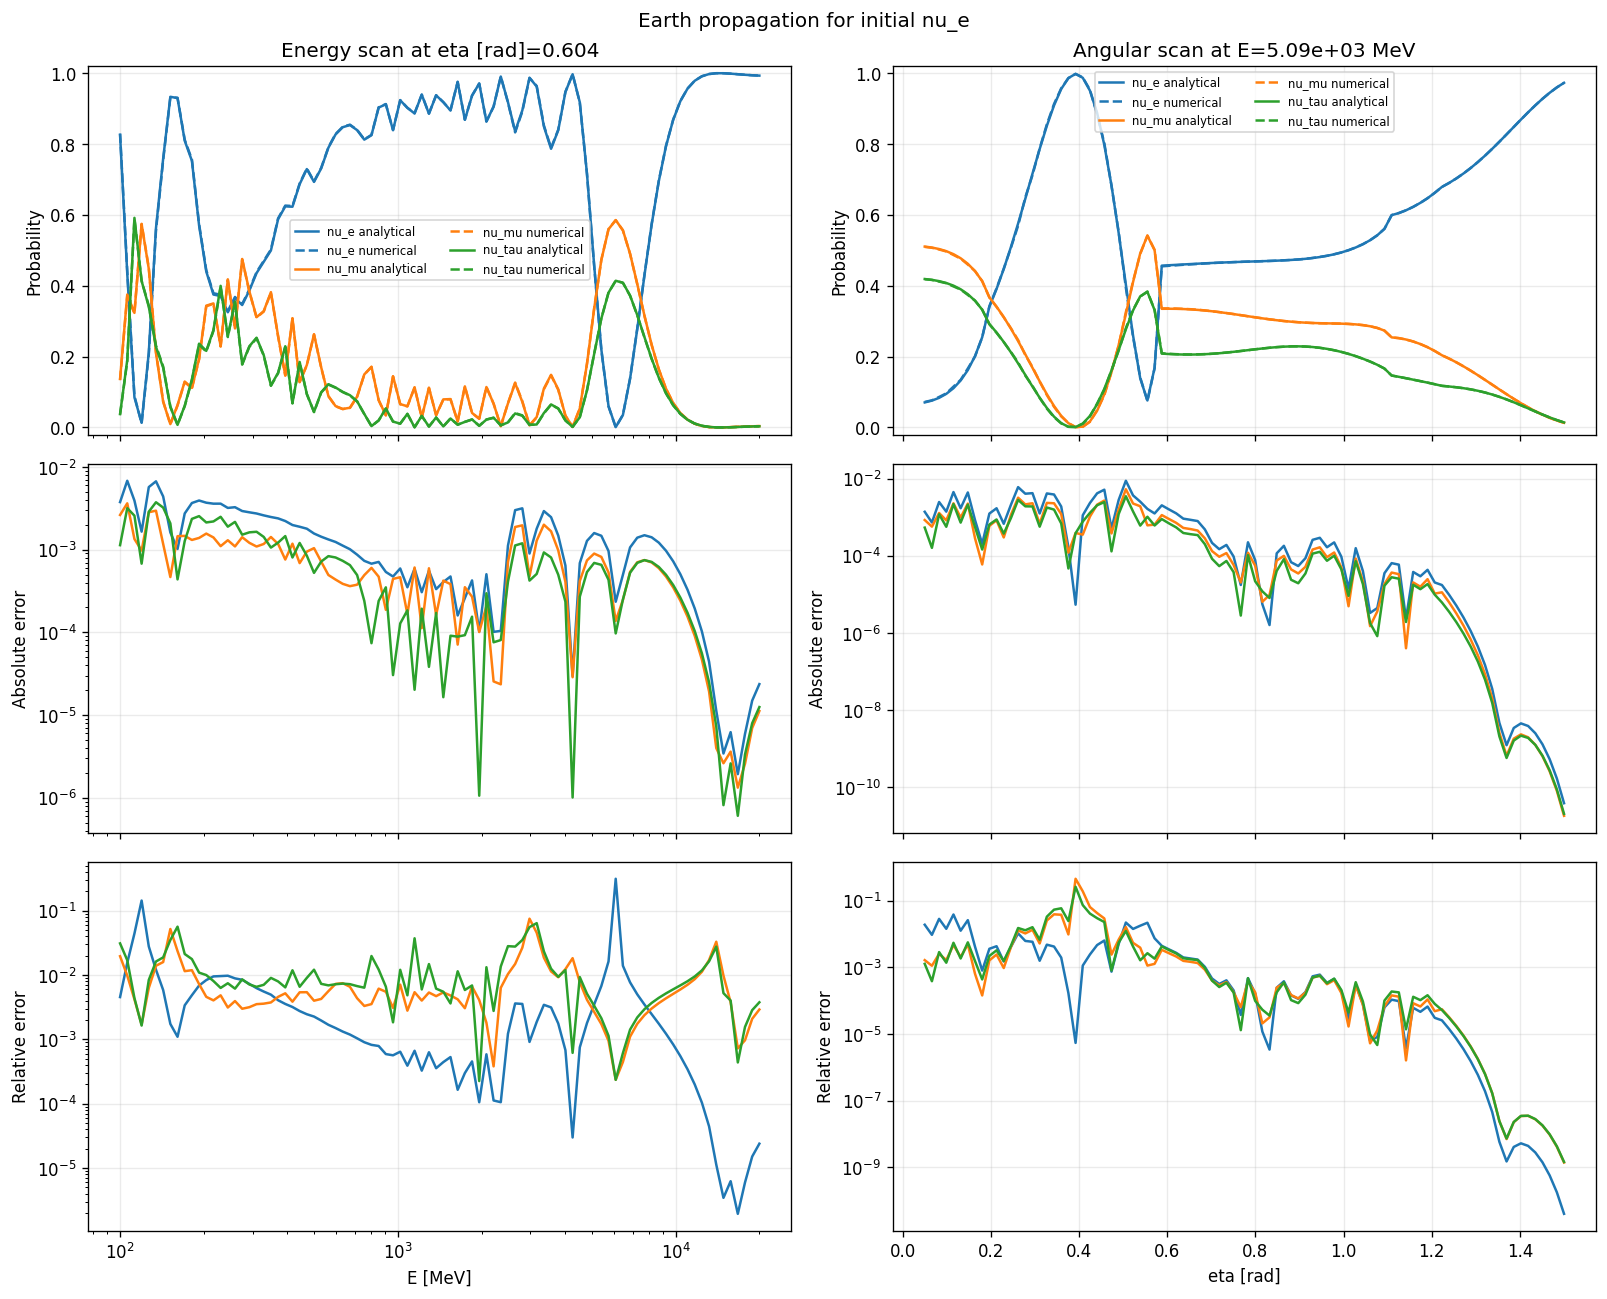

v:\output\validation\intrinsic\intrinsic1_fig1b_earth_slices.png


In [5]:
E_earth = torch.logspace(np.log10(100.0), np.log10(2.0e4), 90, device=DEVICE, dtype=DTYPE)
eta_earth = torch.linspace(0.05, 1.50, 90, device=DEVICE, dtype=DTYPE)

def earth_flavour_grid(method):
    per_state = []
    for state in BASIS:
        per_eta = [earth_probability_state(state, earth, oscillation, E_earth[:, None], eta, DEPTH_M, method=method, massbasis=False, nsteps=N_EARTH_STEPS, context=context, reunitarize=True).reshape(E_earth.numel(), 3) for eta in eta_earth]
        per_state.append(torch.stack(per_eta, dim=1))
    return torch.stack(per_state)

earth_a, earth_n = earth_flavour_grid('analytical'), earth_flavour_grid('numerical')
earth_abs, earth_rel = metrics('pure flavour through Earth', earth_a, earth_n)
heatmap(earth_abs.amax(dim=(0, 3)), earth_rel.amax(dim=(0, 3)), E_earth, eta_earth, 'Earth: analytical versus numerical', 'E [MeV]', 'nadir angle eta [rad]', 'intrinsic1_fig1_earth.png')
comparison_grid(earth_a[0], earth_n[0], E_earth, eta_earth, 0.60, 5000.0, 'Earth propagation for initial nu_e', 'eta [rad]', 'intrinsic1_fig1b_earth_slices.png', log_energy=True)

## 4. Solar neutrinos to the detector

Solar $^8$B neutrinos are produced as $\nu_e$, converted into incoherent mass weights by the solar MSW calculation, and propagated through Earth to the detector. Only the Earth step differs between the two branches. Parallel heatmaps display the maximum absolute and relative errors over final flavour. The $3\times2$ grid compares the three detected flavours near $\eta=0.55$ rad and $E=10$ MeV.

**Expected results:** all flavour probabilities remain normalized. Day–night regeneration is strongest at low nadir angles; analytical–numerical differences should remain small compared with the physical Earth matter effect.

,max_abs,mean_abs,max_rel,normalization_analytical,normalization_numerical
case,,,,,
solar production to detector,0.008926,0.000307,0.025654,1.998401e-15,3.138423e-11


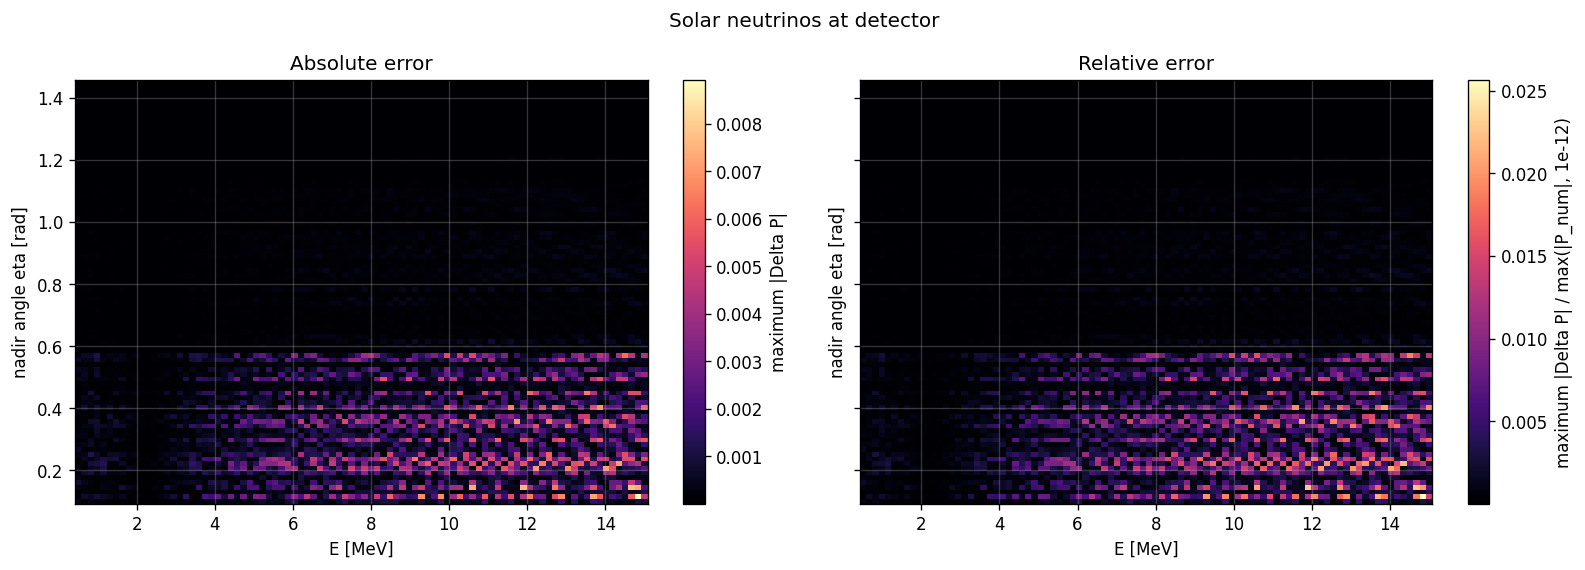

v:\output\validation\intrinsic\intrinsic1_fig2_solar_detector.png


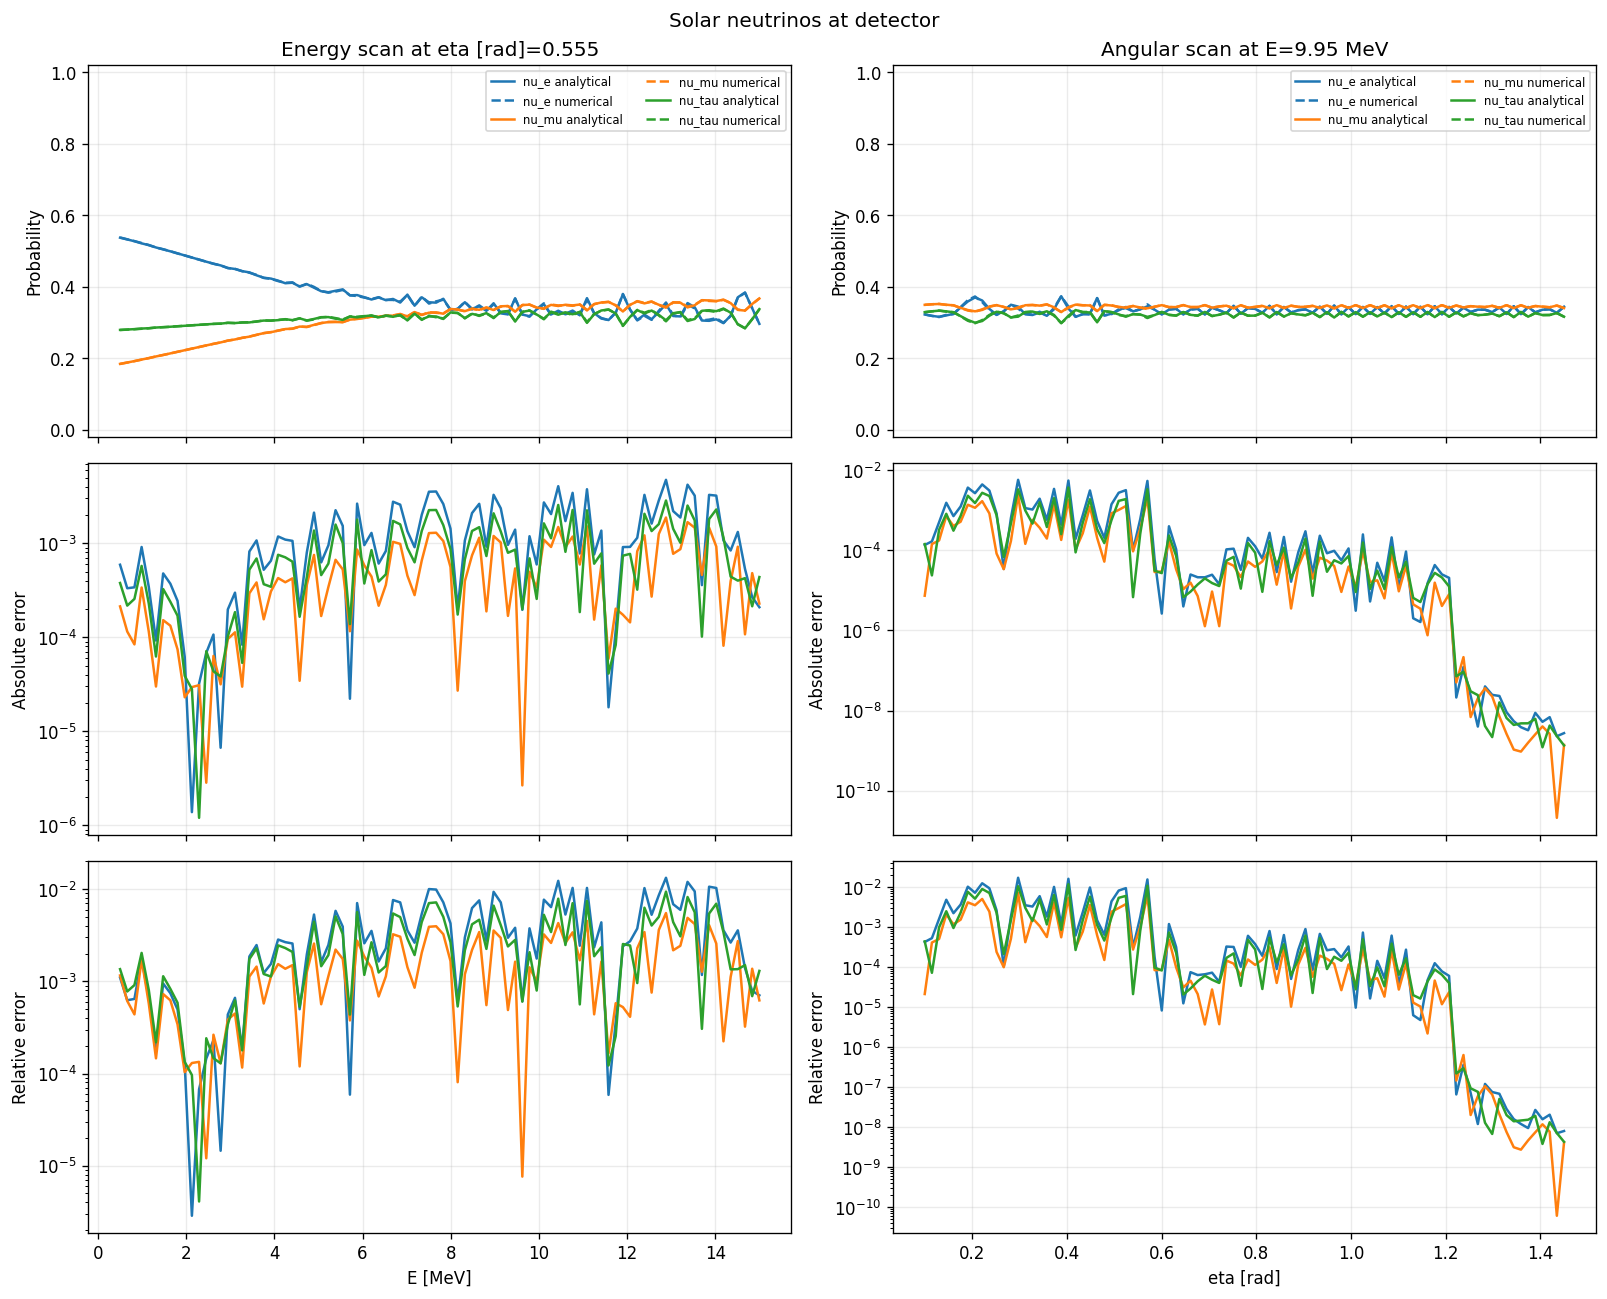

v:\output\validation\intrinsic\intrinsic1_fig2b_solar_detector_slices.png


In [6]:
E_solar = torch.linspace(0.5, 15.0, 90, device=DEVICE, dtype=DTYPE)
eta_solar = torch.linspace(0.10, 1.45, 90, device=DEVICE, dtype=DTYPE)
solar_weights = solar_probability_mass(oscillation, E_solar, solar, '8B')

def solar_detector_grid(method):
    return torch.stack([earth_probability_state(solar_weights, earth, oscillation, E_solar[:, None], eta, DEPTH_M, method=method, massbasis=True, nsteps=N_EARTH_STEPS, context=context, reunitarize=True).reshape(E_solar.numel(), 3) for eta in eta_solar], dim=1)

solar_a, solar_n = solar_detector_grid('analytical'), solar_detector_grid('numerical')
solar_abs, solar_rel = metrics('solar production to detector', solar_a, solar_n)
heatmap(solar_abs.amax(dim=-1), solar_rel.amax(dim=-1), E_solar, eta_solar, 'Solar neutrinos at detector', 'E [MeV]', 'nadir angle eta [rad]', 'intrinsic1_fig2_solar_detector.png')
comparison_grid(solar_a, solar_n, E_solar, eta_solar, 0.55, 10.0, 'Solar neutrinos at detector', 'eta [rad]', 'intrinsic1_fig2b_solar_detector_slices.png')

## 5. Atmospheric neutrinos to the surface

The complete flavour-transition matrix is compared at the Earth surface. The analytical atmosphere uses six cubic local fits; the numerical reference uses 600 density segments. Both plotted errors are maximized over the complete $3\times3$ transition matrix. The $3\times2$ grid selects an initial $\nu_e$ and shows energy dependence near the horizon ($\theta=89^\circ$) and angular dependence near $E=10$ GeV.

**Expected results:** agreement should be especially strong because atmospheric density is low. Differences may grow for near-horizontal trajectories, whose atmospheric path is longest, while every transition-matrix column should sum to one.

,max_abs,mean_abs,max_rel,normalization_analytical,normalization_numerical
case,,,,,
atmosphere production to surface,1.516887e-11,1.560796e-13,0.000091,6.850076e-14,6.685763e-13


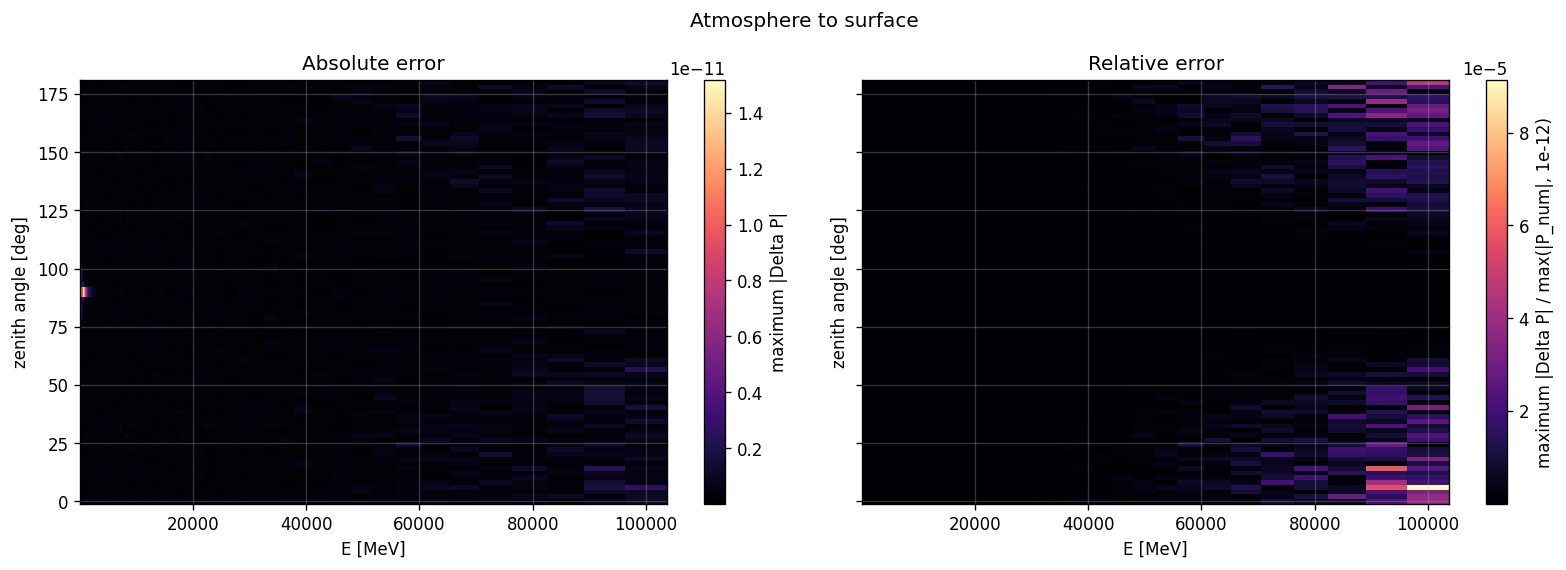

v:\output\validation\intrinsic\intrinsic1_fig3_atmosphere_surface.png


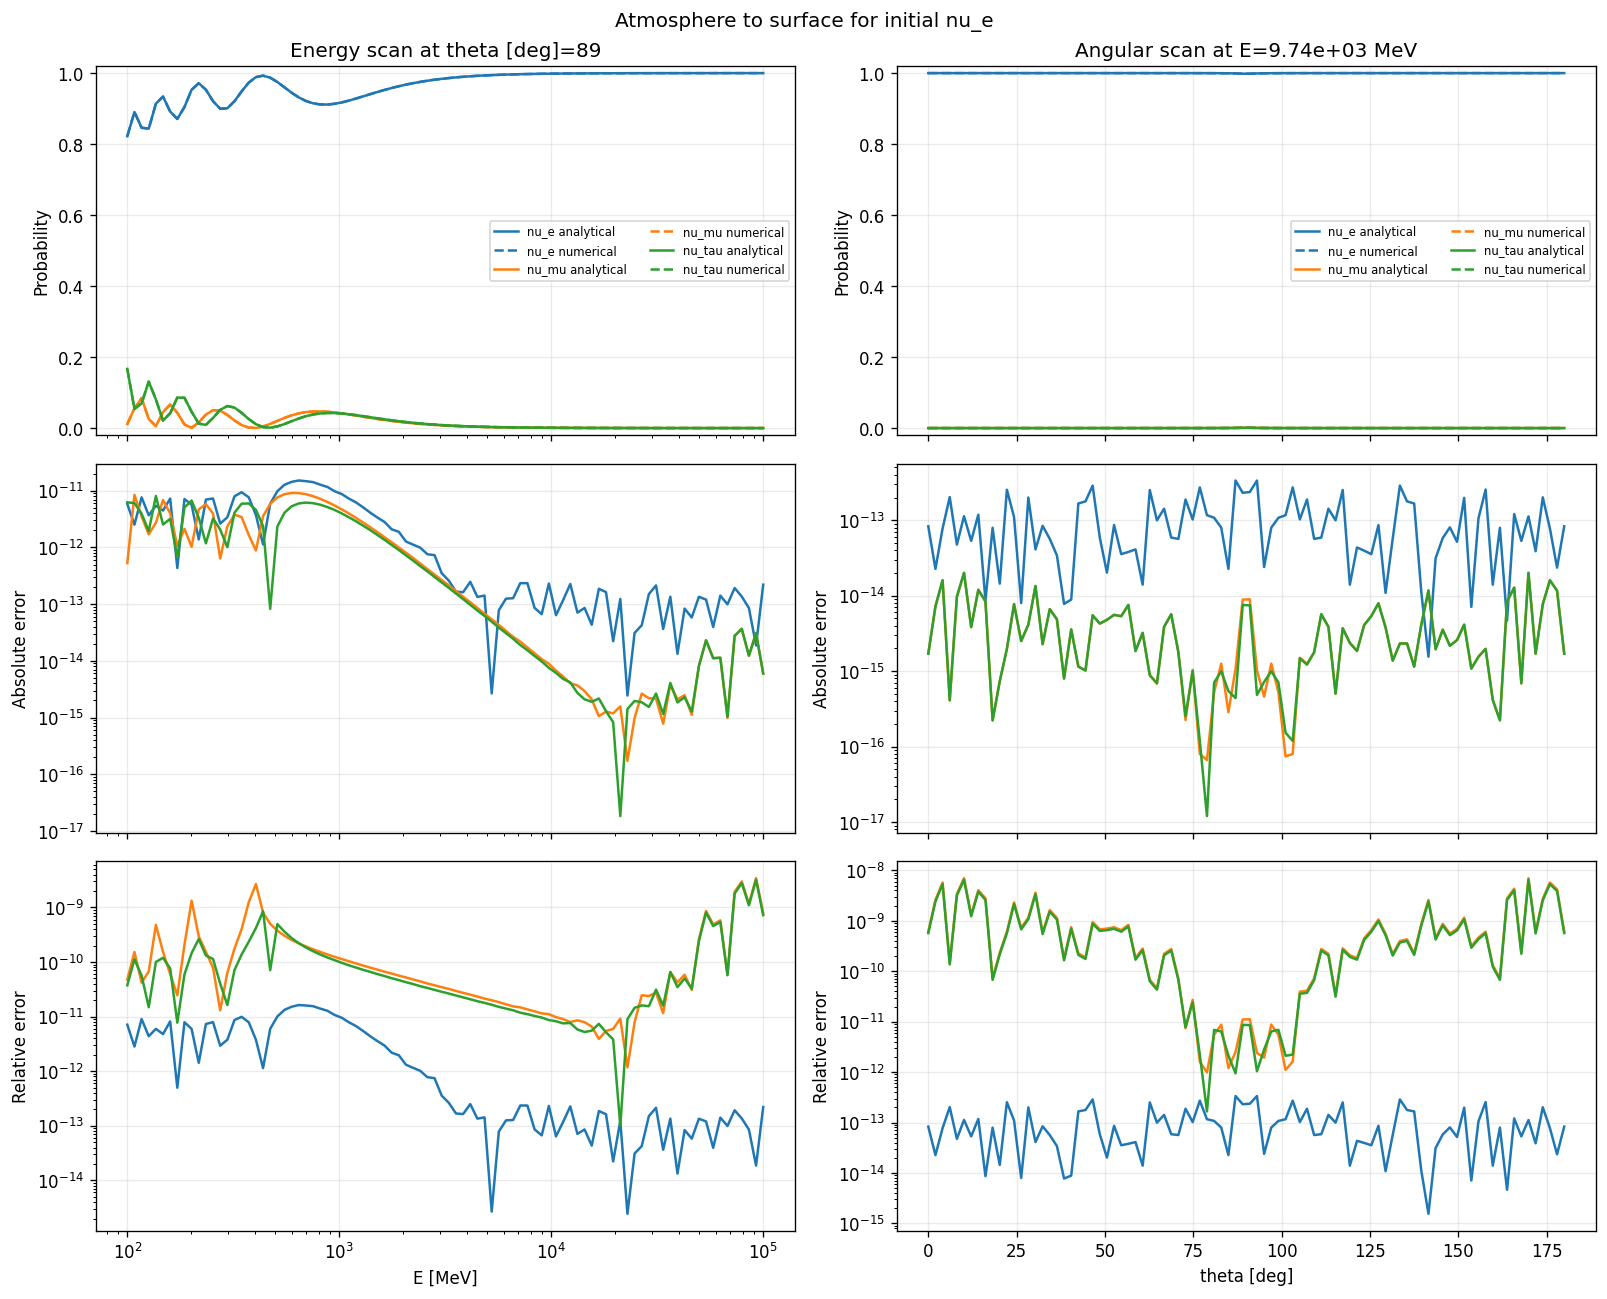

v:\output\validation\intrinsic\intrinsic1_fig3b_atmosphere_surface_slices.png


In [7]:
E_atm = torch.logspace(2.0, 5.0, 90, device=DEVICE, dtype=DTYPE)
theta_atm = torch.linspace(0.0, 180.0, 90, device=DEVICE, dtype=DTYPE)
atm_args = dict(oscillation=oscillation, E_MeV=E_atm[:, None], h_km=25.0, theta_deg=theta_atm[None, :], depth_km=DEPTH_M/1000.0, atmosphere=atmosphere, context=context)
surface_a = atmosphere_probability_transition(**atm_args, method='analytical')
surface_n = atmosphere_probability_transition(**atm_args, method='numerical')
surface_abs, surface_rel = metrics('atmosphere production to surface', surface_a, surface_n)
heatmap(surface_abs.amax(dim=(-2, -1)), surface_rel.amax(dim=(-2, -1)), E_atm, theta_atm, 'Atmosphere to surface', 'E [MeV]', 'zenith angle [deg]', 'intrinsic1_fig3_atmosphere_surface.png')
comparison_grid(surface_a[..., :, 0], surface_n[..., :, 0], E_atm, theta_atm, 89.0, 1.0e4, 'Atmosphere to surface for initial nu_e', 'theta [deg]', 'intrinsic1_fig3b_atmosphere_surface_slices.png', log_energy=True)

## 6. Atmospheric neutrinos to the detector

This comparison preserves amplitudes: first $S_{\rm atm}$ acts on each pure flavour state and then the resulting coherent state is propagated through Earth. The total probability is therefore not constructed by multiplying probability matrices. Parallel heatmaps summarize the maximum absolute and relative errors. The $3\times2$ grid selects an initial $\nu_e$, an up-going trajectory at $\theta=150^\circ$, and an angular scan near $E=5$ GeV.

**Expected results:** down-going events mainly test atmosphere propagation, whereas up-going events also test long Earth chords. The combined probabilities must remain normalized, and the largest discrepancies are expected for up-going, matter-sensitive trajectories.

,max_abs,mean_abs,max_rel,normalization_analytical,normalization_numerical
case,,,,,
atmosphere production to detector,0.014012,0.000267,3.025546,8.482104e-14,8.559820e-13


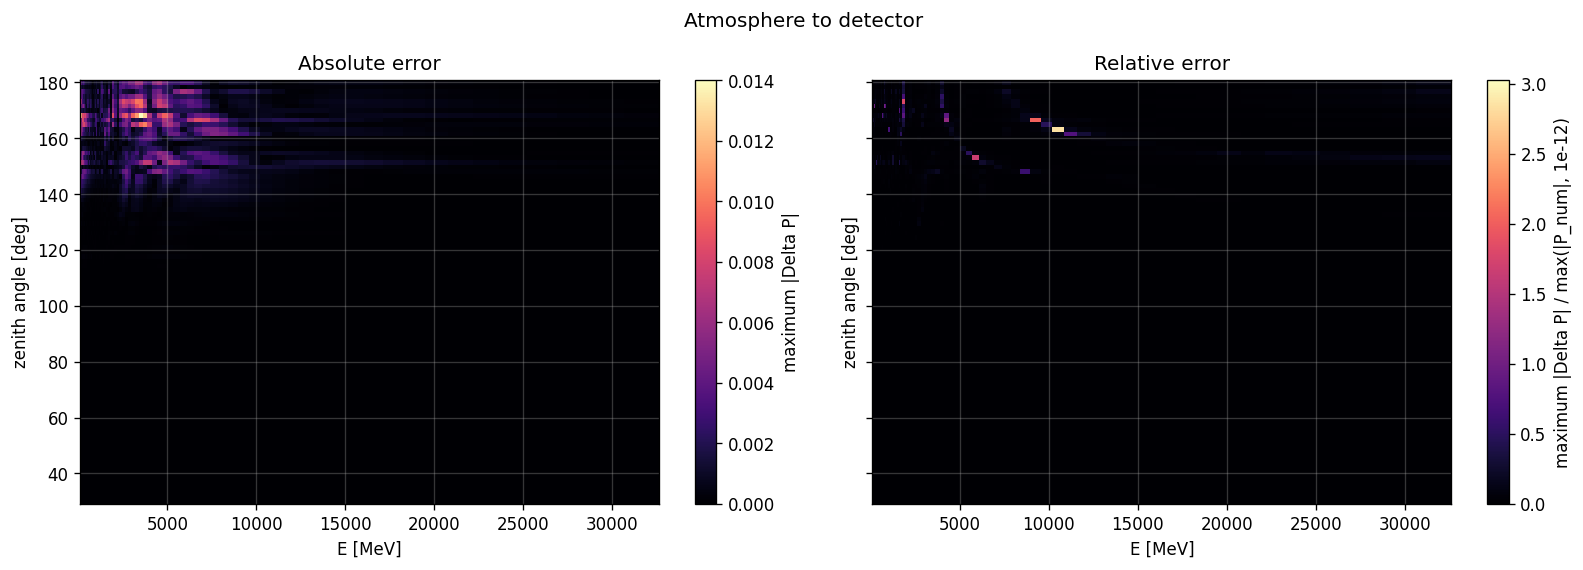

v:\output\validation\intrinsic\intrinsic1_fig4_atmosphere_detector.png


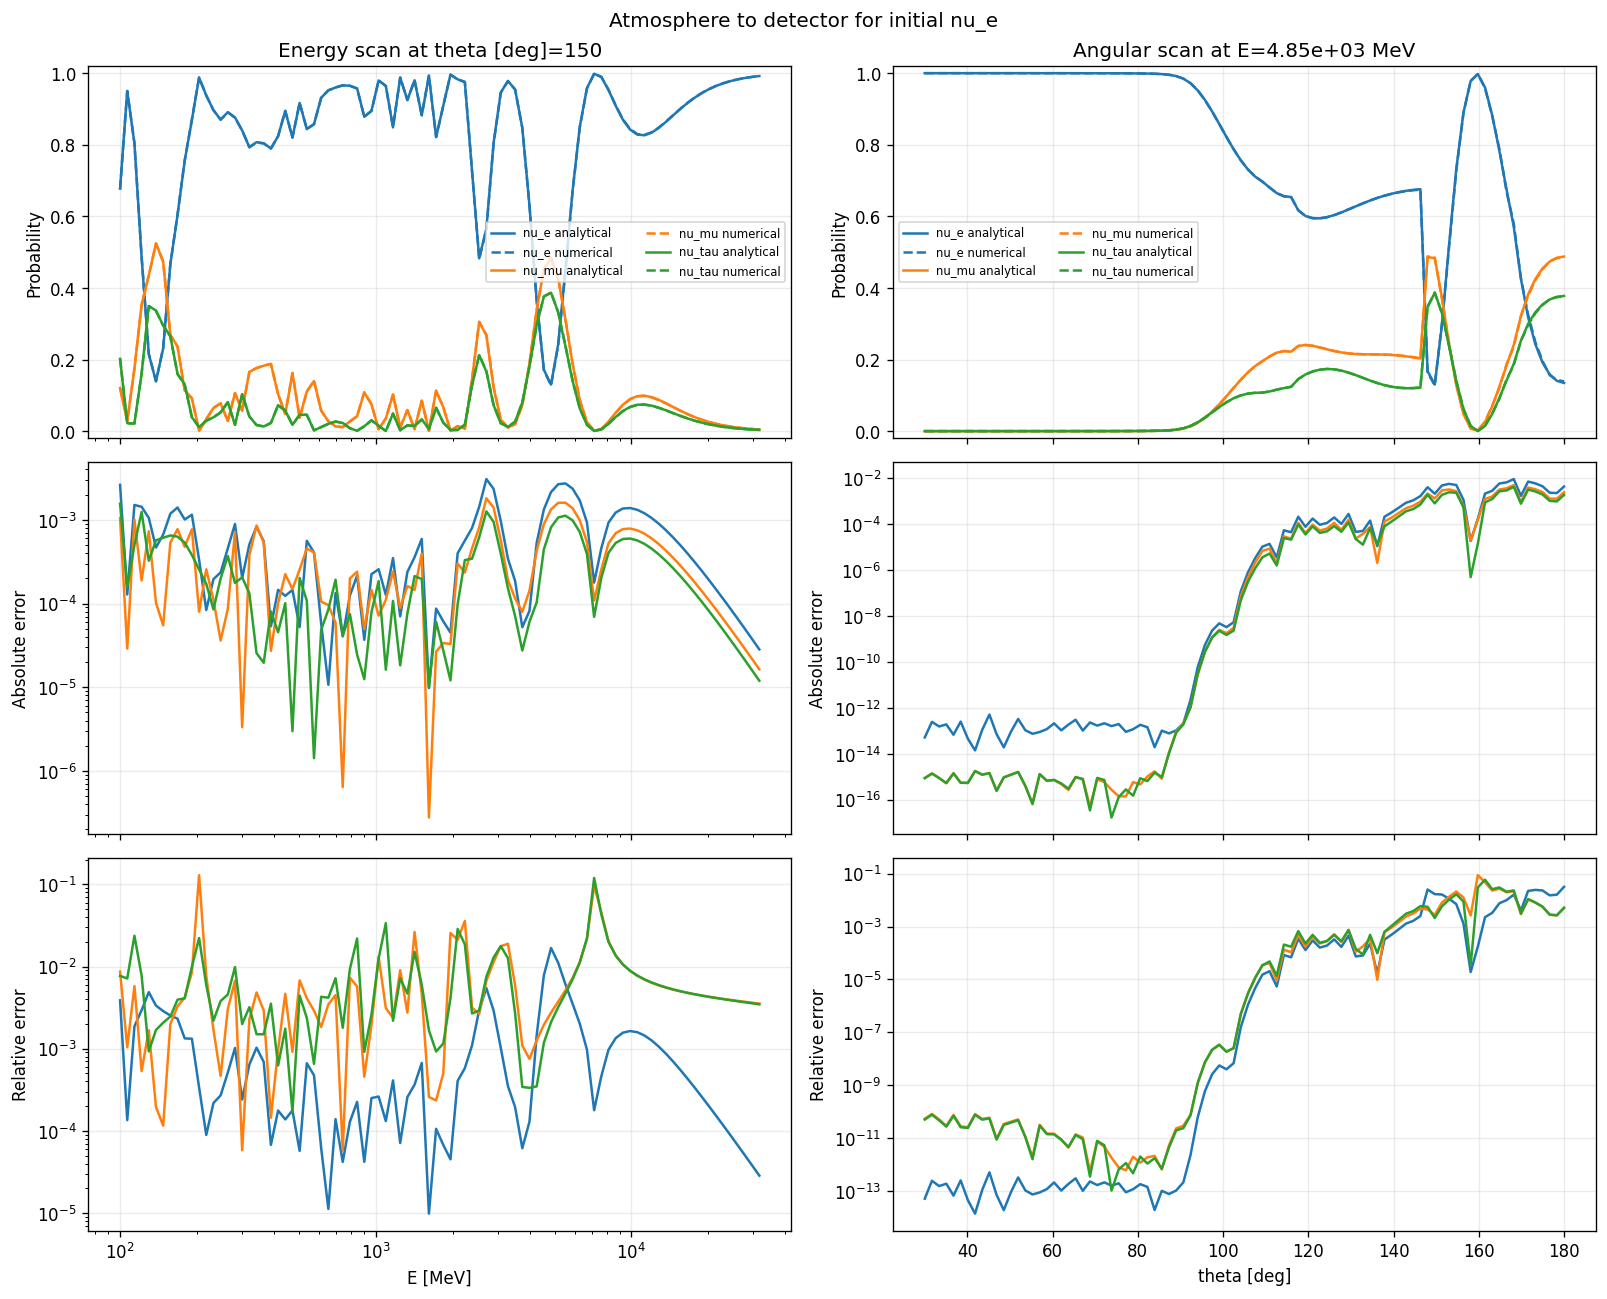

v:\output\validation\intrinsic\intrinsic1_fig4b_atmosphere_detector_slices.png


In [8]:
E_det = torch.logspace(2.0, 4.5, 90, device=DEVICE, dtype=DTYPE)
theta_det = torch.linspace(30.0, 180.0, 90, device=DEVICE, dtype=DTYPE)

def atmosphere_detector_grid(method):
    S_atm, _ = atmosphere_evolutor(oscillation, E_det[:, None], 25.0, theta_det[None, :], DEPTH_M/1000.0, atmosphere=atmosphere, context=context, method=method)
    angle_results = []
    for i_theta, theta in enumerate(theta_det):
        eta = torch.pi - torch.deg2rad(theta)
        state_results = []
        for state in BASIS:
            surface_state = torch.matmul(S_atm[:, i_theta], state)
            state_results.append(earth_probability_state(surface_state, earth, oscillation, E_det[:, None], eta, DEPTH_M, method=method, massbasis=False, nsteps=N_EARTH_STEPS, context=context, reunitarize=True).reshape(E_det.numel(), 3))
        angle_results.append(torch.stack(state_results))
    return torch.stack(angle_results, dim=2)

detector_a, detector_n = atmosphere_detector_grid('analytical'), atmosphere_detector_grid('numerical')
detector_abs, detector_rel = metrics('atmosphere production to detector', detector_a, detector_n)
heatmap(detector_abs.amax(dim=(0, 3)), detector_rel.amax(dim=(0, 3)), E_det, theta_det, 'Atmosphere to detector', 'E [MeV]', 'zenith angle [deg]', 'intrinsic1_fig4_atmosphere_detector.png')
comparison_grid(detector_a[0], detector_n[0], E_det, theta_det, 150.0, 5000.0, 'Atmosphere to detector for initial nu_e', 'theta [deg]', 'intrinsic1_fig4b_atmosphere_detector_slices.png', log_energy=True)

## 7. Summary

The table collects maximum and mean discrepancies and the probability-normalization error for all four scenarios. It is also exported as `validation_intrinsic1_summary.csv`.

**Expected results:** every metric is finite, normalization errors remain below $10^{-8}$, and the numerical and perturbative methods show consistent physical trends across the four propagation chains.

In [9]:
summary = pd.DataFrame(summaries).set_index('case')
display(summary.style.format('{:.3e}'))
summary.to_csv(OUTPUT_DIR / 'validation_intrinsic1_summary.csv')
assert np.isfinite(summary.to_numpy()).all(), 'Validation produced non-finite metrics.'
assert summary[['normalization_analytical', 'normalization_numerical']].to_numpy().max() < 1e-8
print('All four intrinsic comparisons completed successfully.')

,max_abs,mean_abs,max_rel,normalization_analytical,normalization_numerical
case,,,,,
pure flavour through Earth,1.164e-02,4.626e-04,8.614e+00,2.665e-15,3.291e-13
solar production to detector,8.926e-03,3.073e-04,2.565e-02,1.998e-15,3.138e-11
atmosphere production to surface,1.517e-11,1.561e-13,9.138e-05,6.850e-14,6.686e-13
atmosphere production to detector,1.401e-02,2.667e-04,3.026e+00,8.482e-14,8.560e-13


All four intrinsic comparisons completed successfully.


### Interpretation

The numerical branch is the discretized reference, while the analytical branch is a first-order perturbative approximation. Differences should be interpreted together with probability normalization and convergence under increasing `nsteps`, `perturbative_segments`, or `perturbative_degree`. The atmospheric-to-detector section is the strongest end-to-end test because it compares both propagation stages without discarding coherence at the surface.